<a href="https://colab.research.google.com/github/shivanshukashyap284-droid/-Project-Name---Daily-Calorie-Requirement-Prediction-Health-Data-Analysis-using-Python/blob/main/pro3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import pandas as pd


In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
print(df.shape)

(200, 5)


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


<Axes: ylabel='count'>

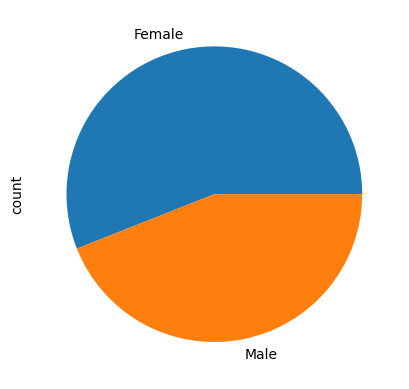

In [ ]:
df['Gender'].value_counts().plot(kind='pie')

In [ ]:
import plotly.express as px

fig = px.pie(
    df,
    names='Gender',
    title='Gender Distribution of Customers',
    hole=0.4,
    width=800,
    height=600
)

fig.show()

In [ ]:
fig=px.histogram(df,x='Age',nbins=10,color='Gender')
fig.update_layout(
    bargap=0.02,
    width=500,
    height=500)
fig.show()

In [ ]:
# Age Distribution (Histogram)

fig = px.histogram(
    df,
    x='Age',
    nbins=15,
    title='Age Distribution of Customers',
    marginal='box',
    width=800,
    height=600
)

fig.show()

In [ ]:
fig = px.histogram(
    df,
    x='Annual Income (k$)',
    nbins=15,
    title='Age Distribution of Customers',
    marginal='box',
    width=800,
    height=600
)

fig.show()

In [ ]:
# Scatter Plot: Age vs Spending Score

fig = px.scatter(
    df,
    x='Age',
    y='Spending Score (1-100)',
    color='Gender',
    title='Age vs Spending Score',
    width=800,
    height=600
)

fig.update_traces(marker=dict(size=10))
fig.show()

In [ ]:
# Scatter Plot: Age vs Spending Score

fig = px.scatter(
    df,
    x='Age',
    y='Annual Income (k$)',
    color='Gender',
    title='Age vs Spending Score',
    width=800,
    height=600
)

fig.update_traces(marker=dict(size=10))
fig.show()

In [ ]:
df["Gender"] = df["Gender"].map({'Male': 1, 'Female': 0})


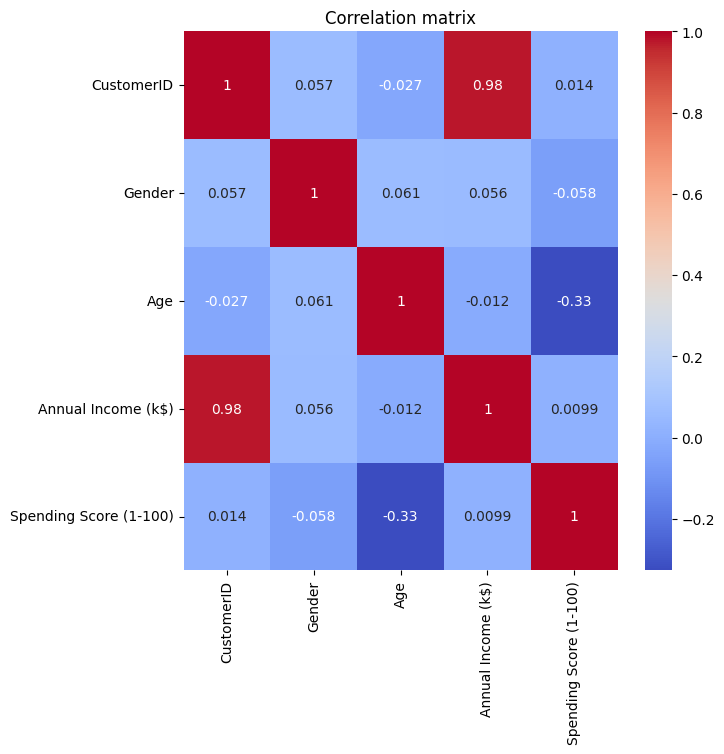

In [ ]:
corr = df.corr()

plt.figure(figsize=(7, 7))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation matrix")

plt.show()

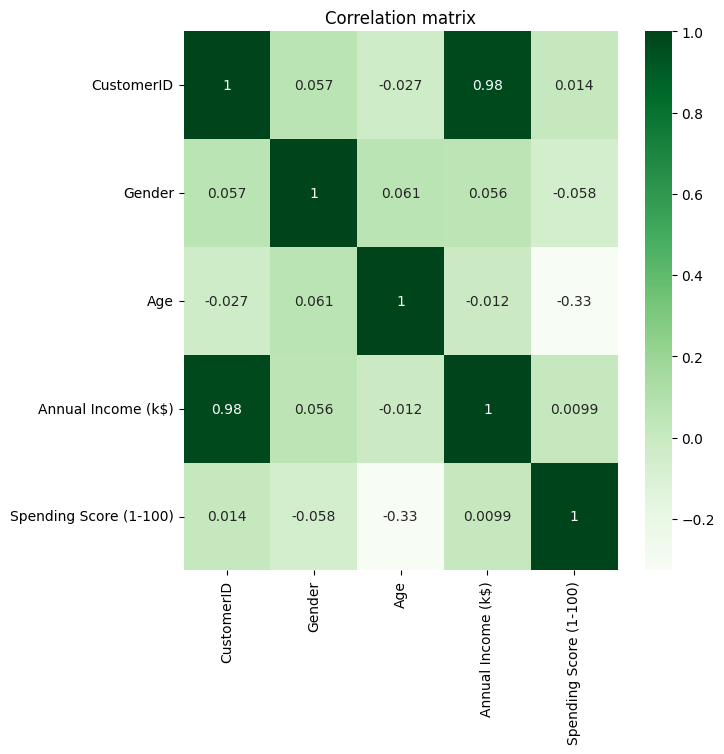

In [ ]:
corr = df.corr()

plt.figure(figsize=(7, 7))

sns.heatmap(corr, annot=True, cmap='Greens')

plt.title("Correlation matrix")


plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10,

)

df["cluster"] = kmeans.fit_predict(
    df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,0
1,2,1,21,15,81,4
2,3,0,20,16,6,0
3,4,0,23,16,77,4
4,5,0,31,17,40,0
...,...,...,...,...,...,...
195,196,0,35,120,79,2
196,197,0,45,126,28,3
197,198,1,32,126,74,2
198,199,1,32,137,18,3


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,0
1,2,1,21,15,81,4
2,3,0,20,16,6,0
3,4,0,23,16,77,4
4,5,0,31,17,40,0


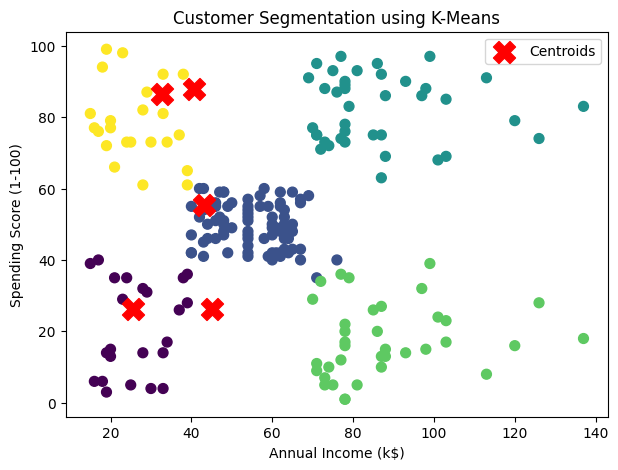

In [ ]:
# Visualize clusters
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['cluster'],
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=250,
    color='red',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Gender',   # Optional
    title='3D Customer Distribution',
    width=900,
    height=700
)

fig.show()